# Comprehensive Dataset Analysis for Thesis

This notebook provides a thorough analysis of a temporal graph dataset. It is designed to generate high-quality figures, tables, and metrics suitable for direct inclusion in a LaTeX thesis.

The analysis covers:
1.  **Dataset Overview**: Basic statistics and dataset dimensions.
2.  **Feature Analysis**: Distribution, correlation, missing values, and temporal trends of node features.
3.  **Graph Structure Analysis**: Properties of the adjacency matrices, including sparsity, degree distribution, connectivity, and centrality measures.
4.  **Temporal Evolution**: How graph and feature properties change over time.
5.  **Combined Feature and Graph Analysis**: Exploring the relationship between node features and their position within the graph.

## 1. Setup and Data Loading

First, we import the necessary libraries and define the paths to our train, validation, and test datasets. We then load them using the `MarketAnalyzer` class from our utility script.

In [11]:
# Import required libraries
import sys
import os
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx
from scipy.stats import entropy

# Add the project root to the Python path to allow importing dataset_analyzer
project_root = Path.cwd().parent
if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

from dataset_analyzer import MarketAnalyzer

# Set plot style for thesis-quality figures
sns.set_theme(style="whitegrid", context="paper", font_scale=1.2)
plt.rcParams['figure.figsize'] = (10, 6)
FIGURE_OUTPUT_PATH = Path('./thesis_figures')
FIGURE_OUTPUT_PATH.mkdir(exist_ok=True)

def save_figure(filename):
    """Helper function to save figures in a consistent format."""
    plt.savefig(FIGURE_OUTPUT_PATH / f"{filename}.pdf", format='pdf', bbox_inches='tight')
    plt.savefig(FIGURE_OUTPUT_PATH / f"{filename}.png", format='png', bbox_inches='tight', dpi=300)
    print(f"Figure saved to {FIGURE_OUTPUT_PATH / f'{filename}.pdf'}")

In [12]:
# --- Configuration ---
MARKET = 'SSE'
NORMALIZATION = 'zscore'
WINDOW_SIZE = 14

# Define dataset paths
base_path = project_root / 'data' / 'datasets' / 'graph'
train_path = base_path / f"{MARKET}_Train_2016-05-01_2017-06-30_{WINDOW_SIZE}_{NORMALIZATION}"
val_path = base_path / f"{MARKET}_Validation_2017-07-01_2017-12-31_{WINDOW_SIZE}_{NORMALIZATION}"
test_path = base_path / f"{MARKET}_Test_2018-01-01_2019-12-31_{WINDOW_SIZE}_{NORMALIZATION}"

# Load datasets using the MarketAnalyzer
train_analyzer = MarketAnalyzer(train_path, adj_minmax=True, threshold=0.004)
val_analyzer = MarketAnalyzer(val_path, train_path=train_path, adj_minmax=True, threshold=0.004)
test_analyzer = MarketAnalyzer(test_path, train_path=train_path, adj_minmax=True, threshold=0.004)

analyzers = {'Train': train_analyzer, 'Validation': val_analyzer, 'Test': test_analyzer}

print("Datasets loaded successfully.")

|             Dataset Information             |
| Market Name:         SSE                     |
| Time Period:         Train                   |
| Start Date:          2016-05-01              |
| End Date:            2017-06-30              |
| Window Size:         14                      |
| Normalizer:          zscore                  |
| Number of Features:  5                       |
| Number of Nodes:     128                     |
| Number of Snapshots: 271                     |
Folder analysis_results already exists at /extra/mbisoffi/tests/TemporalGNNReview/code/data/datasets/graph/SSE_Train_2016-05-01_2017-06-30_14_zscore
|             Dataset Information             |
| Market Name:         SSE                     |
| Time Period:         Validation              |
| Start Date:          2017-07-01              |
| End Date:            2017-12-31              |
| Window Size:         14                      |
| Normalizer:          zscore                  |
| Number of Features

### 1.1. Dataset Overview

We begin by generating a summary table that provides an overview of the key dimensions of each dataset split.

In [13]:
overview_data = []
for name, analyzer in analyzers.items():
    info = {
        'Dataset': name,
        'Num Nodes': analyzer.num_nodes,
        'Num Features': analyzer.num_features,
        'Num Snapshots': analyzer.num_snapshots
    }
    overview_data.append(info)

overview_df = pd.DataFrame(overview_data).set_index('Dataset')

print("--- Dataset Overview ---")
display(overview_df)

print("\n--- LaTeX Table ---")
print(overview_df.to_latex(caption='Overview of dataset dimensions.', label='tab:dataset_overview'))

--- Dataset Overview ---


,Num Nodes,Num Features,Num Snapshots
Dataset,,,
Train,128,5,271
Validation,128,5,112
Test,128,5,474



--- LaTeX Table ---
\begin{table}
\caption{Overview of dataset dimensions.}
\label{tab:dataset_overview}
\begin{tabular}{lrrr}
\toprule
 & Num Nodes & Num Features & Num Snapshots \\
Dataset &  &  &  \\
\midrule
Train & 128 & 5 & 271 \\
Validation & 128 & 5 & 112 \\
Test & 128 & 5 & 474 \\
\bottomrule
\end{tabular}
\end{table}




### 1.2. Cross-Dataset Comparison

Before diving deeper, it's crucial to verify that the train, validation, and test sets are statistically similar. Significant differences could indicate issues with the data splitting process and lead to a model that generalizes poorly. Here, we compare key distributions across the three dataset splits.


Figure saved to thesis_figures/cross_dataset_degree_distribution.pdf


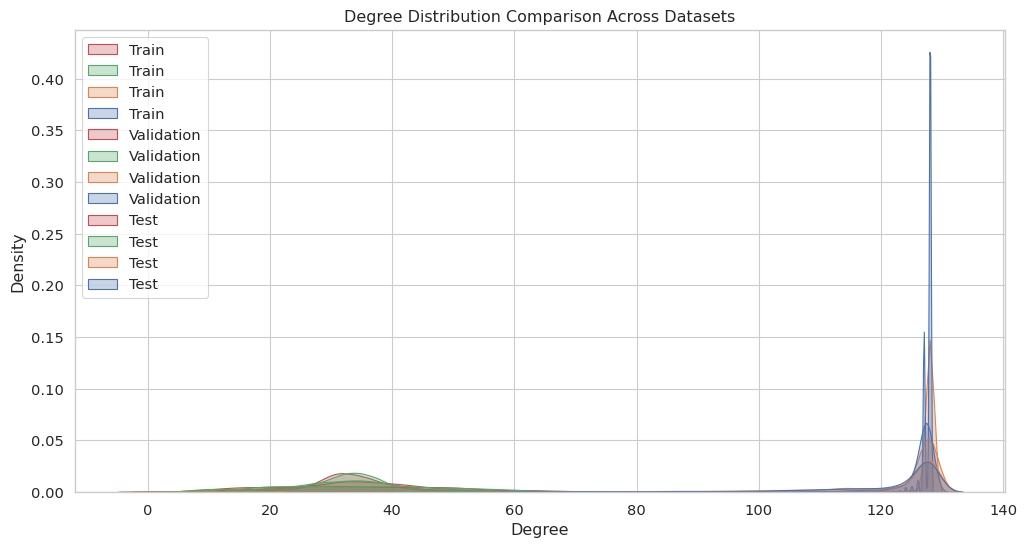

Figure saved to thesis_figures/cross_dataset_feature_distribution.pdf


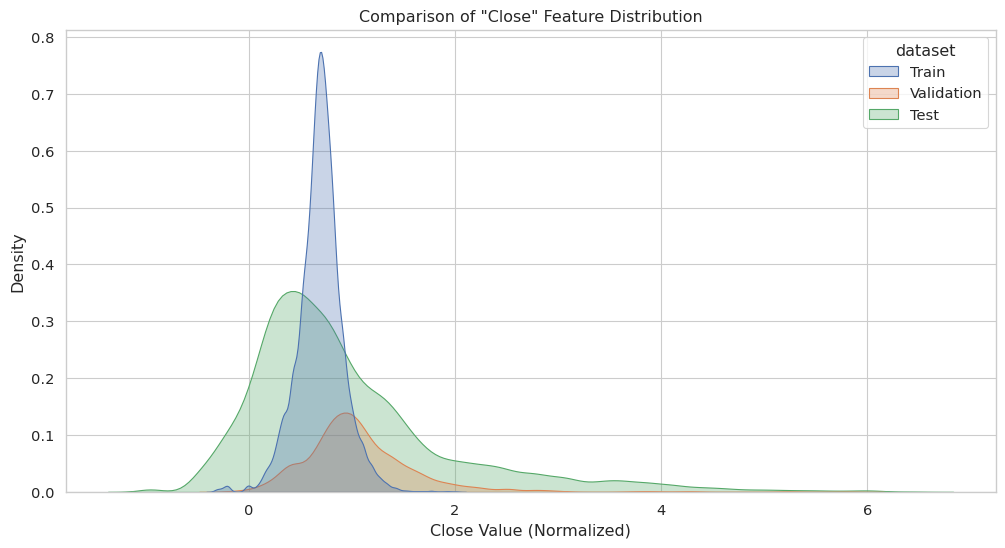

AttributeError: 'MarketAnalyzer' object has no attribute 'get_class_dist'

In [14]:

# --- 1. Compare Degree Distribution ---
plt.figure(figsize=(12, 6))
for name, analyzer in analyzers.items():
    degrees = analyzer.get_degree_dist()
    sns.kdeplot(degrees, label=name, fill=True, alpha=0.3)
plt.title('Degree Distribution Comparison Across Datasets')
plt.xlabel('Degree')
plt.ylabel('Density')
plt.legend()
plt.grid(True)
save_figure('cross_dataset_degree_distribution')
plt.show()

# --- 2. Compare a Key Node Feature Distribution (e.g., 'Close') ---
feature_data = []
for name, analyzer in analyzers.items():
    df = analyzer.analyze_node_features()
    df['dataset'] = name
    feature_data.append(df)

full_feature_df = pd.concat(feature_data)
plt.figure(figsize=(12, 6))
sns.kdeplot(data=full_feature_df, x='Close', hue='dataset', fill=True, alpha=0.3)
plt.title('Comparison of "Close" Feature Distribution')
plt.xlabel('Close Value (Normalized)')
plt.ylabel('Density')
plt.grid(True)
save_figure('cross_dataset_feature_distribution')
plt.show()

# --- 3. Compare Up/Down Class Distribution ---
class_ratios = {name: analyzer.get_class_dist() for name, analyzer in analyzers.items()}
class_df = pd.DataFrame(class_ratios).T.rename(columns={0: 'Down', 1: 'Up'})

class_df.plot(kind='bar', stacked=True, figsize=(10, 6), rot=0)
plt.title('Up/Down Class Distribution Comparison')
plt.ylabel('Proportion')
plt.xlabel('Dataset')
for index, row in enumerate(class_df.itertuples()):
    if row.Down > 0:
        plt.text(index, row.Down / 2, f'{row.Down:.2%}', ha='center', va='center', color='white', weight='bold')
    if row.Up > 0:
        plt.text(index, row.Down + (row.Up / 2), f'{row.Up:.2%}', ha='center', va='center', color='white', weight='bold')
save_figure('cross_dataset_class_distribution')
plt.show()

# --- 4. Compare Graph Connectivity ---
connectivity_scores = {name: analyzer.get_connectivity() for name, analyzer in analyzers.items()}
connectivity_df = pd.DataFrame.from_dict(connectivity_scores, orient='index', columns=['Connectivity'])

plt.figure(figsize=(10, 5))
sns.barplot(x=connectivity_df.index, y=connectivity_df['Connectivity'])
plt.title('Graph Connectivity Comparison')
plt.ylabel('Connectivity Score')
plt.xlabel('Dataset')
plt.grid(axis='y')
save_figure('cross_dataset_connectivity')
plt.show()


## 2. Feature Analysis

In this section, we conduct a deep dive into the node features. We analyze their statistical properties, distributions, correlations, and temporal behavior.

### 2.1. Feature Statistics and Missing Values

We compute descriptive statistics for each feature in the training set and check for missing values across all datasets.

In [15]:
# We focus on the training set for deep feature analysis
features_df = train_analyzer.analyze_node_features()

# --- Feature Statistics ---
feature_stats = features_df[train_analyzer.features].describe()
print("--- Feature Statistics (Training Set) ---")
display(feature_stats)
print("\n--- LaTeX Table ---")
print(feature_stats.to_latex(caption='Descriptive statistics for node features in the training set.', label='tab:feature_stats', float_format="%.3f"))

# --- Missing Values Check ---
missing_values_data = []
for name, analyzer in analyzers.items():
    df = analyzer.analyze_node_features()
    missing_pct = df.isnull().sum() / len(df) * 100
    missing_pct.name = name
    missing_values_data.append(missing_pct)

missing_df = pd.concat(missing_values_data, axis=1)
print("\n--- Missing Value Percentages (%s) ---")
display(missing_df)

--- Feature Statistics (Training Set) ---


,Close,High,Low,Open,Volume
count,34688.000000,34688.000000,34688.000000,34688.000000,34688.000000
mean,0.694027,0.693645,0.694417,0.694078,0.430741
std,0.224104,0.226476,0.221760,0.223656,0.615907
min,-0.327968,-0.328791,-0.329770,-0.329297,-0.687483
25%,0.576091,0.573174,0.579389,0.576772,0.000000
50%,0.697138,0.695368,0.699626,0.697944,0.278015
75%,0.813044,0.812985,0.811437,0.812705,0.716520
max,2.025430,2.059504,2.009122,2.024797,3.808652



--- LaTeX Table ---
\begin{table}
\caption{Descriptive statistics for node features in the training set.}
\label{tab:feature_stats}
\begin{tabular}{lrrrrr}
\toprule
 & Close & High & Low & Open & Volume \\
\midrule
count & 34688.000 & 34688.000 & 34688.000 & 34688.000 & 34688.000 \\
mean & 0.694 & 0.694 & 0.694 & 0.694 & 0.431 \\
std & 0.224 & 0.226 & 0.222 & 0.224 & 0.616 \\
min & -0.328 & -0.329 & -0.330 & -0.329 & -0.687 \\
25% & 0.576 & 0.573 & 0.579 & 0.577 & 0.000 \\
50% & 0.697 & 0.695 & 0.700 & 0.698 & 0.278 \\
75% & 0.813 & 0.813 & 0.811 & 0.813 & 0.717 \\
max & 2.025 & 2.060 & 2.009 & 2.025 & 3.809 \\
\bottomrule
\end{tabular}
\end{table}


--- Missing Value Percentages (%s) ---


,Train,Validation,Test
Close,0.0,0.0,0.0
High,0.0,0.0,0.0
Low,0.0,0.0,0.0
Open,0.0,0.0,0.0
Volume,0.0,0.0,0.0
node_idx,0.0,0.0,0.0
ticker,0.0,0.0,0.0
snapshot_idx,0.0,0.0,0.0


### 2.2. Feature Distributions

Visualizing the distribution of each feature helps us understand their underlying patterns.

Figure saved to thesis_figures/feature_distributions.pdf


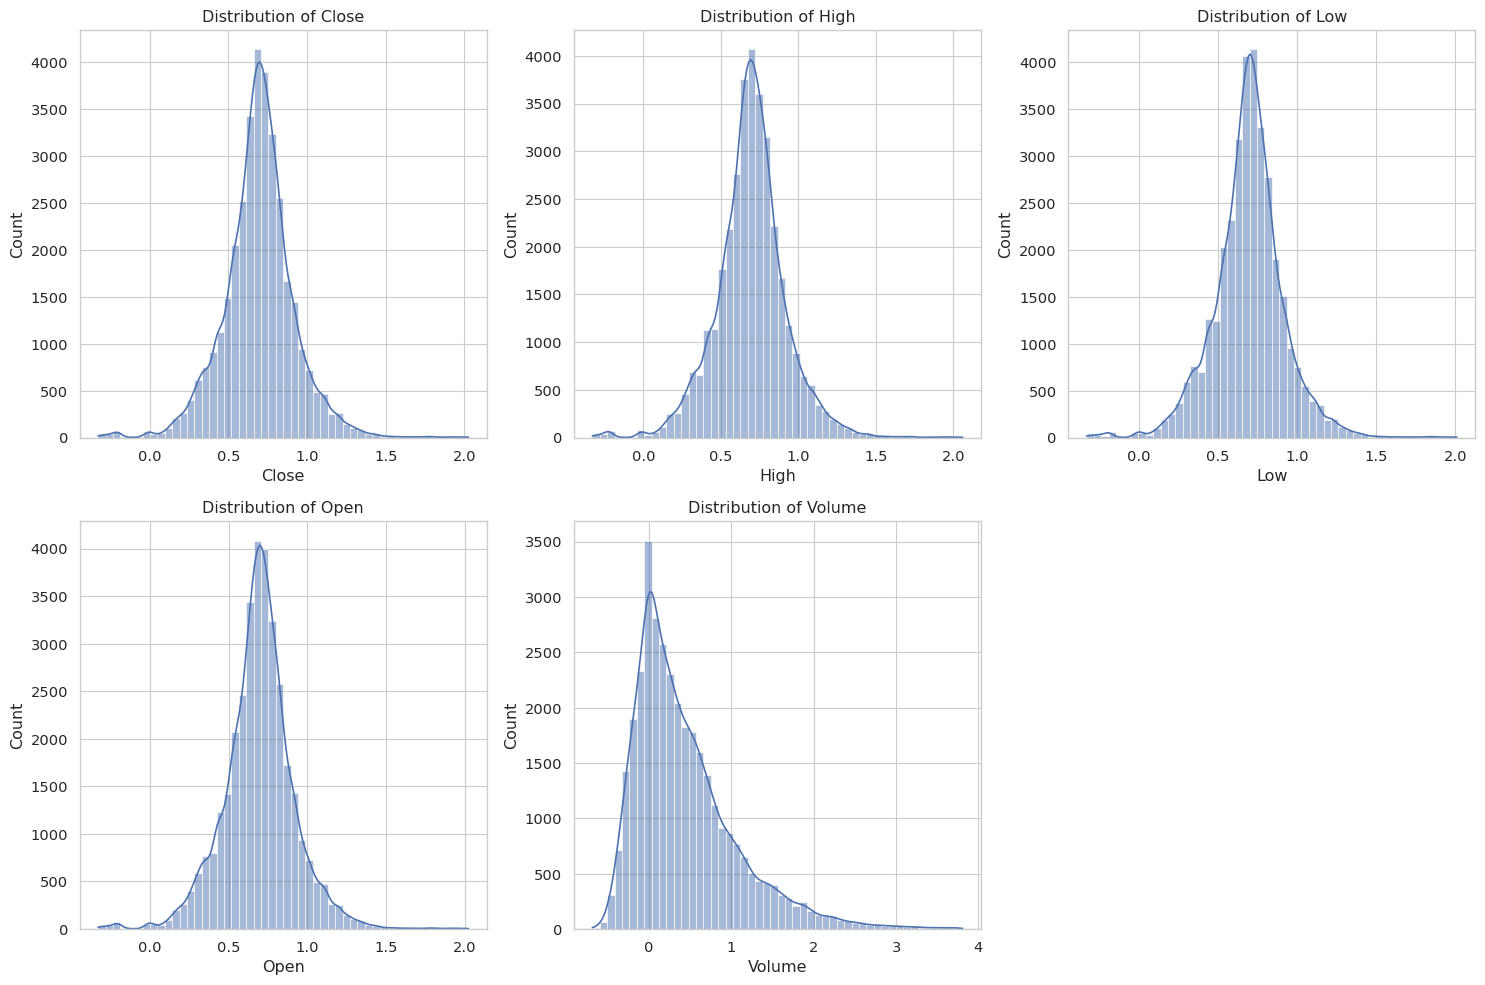

In [16]:
plt.figure(figsize=(15, 10))
for i, feature in enumerate(train_analyzer.features):
    plt.subplot(2, 3, i + 1)
    sns.histplot(features_df[feature], kde=True, bins=50)
    plt.title(f'Distribution of {feature}')
plt.tight_layout()
save_figure('feature_distributions')
plt.show()

### 2.3. Feature Correlation

A correlation matrix reveals linear relationships between features.

Figure saved to thesis_figures/feature_correlation_matrix.pdf


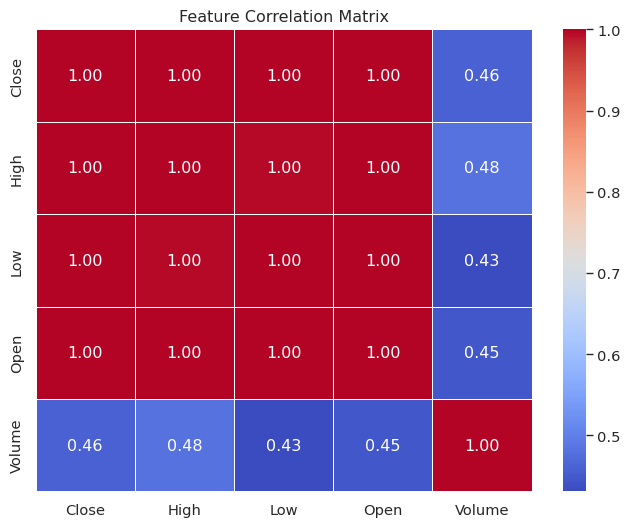

In [17]:
correlation_matrix = features_df[train_analyzer.features].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=.5)
plt.title('Feature Correlation Matrix')
save_figure('feature_correlation_matrix')
plt.show()

### 2.4. Feature Entropy

Feature entropy measures the predictability of a feature. Higher entropy implies less predictability.

Figure saved to thesis_figures/feature_entropy.pdf


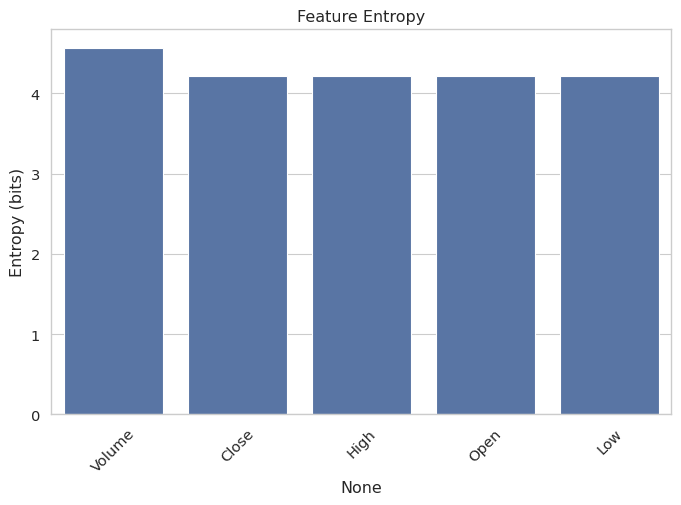

--- Feature Entropy ---


,Entropy
Volume,4.566753
Close,4.219410
High,4.215438
Open,4.214118
Low,4.210377


In [18]:
def calculate_entropy(series, bins=50):
    """Calculates the entropy of a continuous series."""
    counts = np.histogram(series, bins=bins)[0]
    return entropy(counts, base=2)

feature_entropy = {feat: calculate_entropy(features_df[feat]) for feat in train_analyzer.features}
entropy_series = pd.Series(feature_entropy).sort_values(ascending=False)

plt.figure(figsize=(8, 5))
sns.barplot(x=entropy_series.index, y=entropy_series.values)
plt.title('Feature Entropy')
plt.ylabel('Entropy (bits)')
plt.xticks(rotation=45)
save_figure('feature_entropy')
plt.show()

print("--- Feature Entropy ---")
display(entropy_series.to_frame('Entropy'))

## 3. Graph Structure Analysis

This section focuses on the properties of the graph itself, derived from the adjacency matrices.

### 3.1. Adjacency Matrix Visualization and Sparsity

We visualize the adjacency matrix of the first snapshot and compute sparsity statistics.

Adjacency matrix shape: (128, 128)
Figure saved to thesis_figures/adjacency_matrix_first_snapshot.pdf
Figure saved to thesis_figures/adjacency_matrix_first_snapshot.pdf


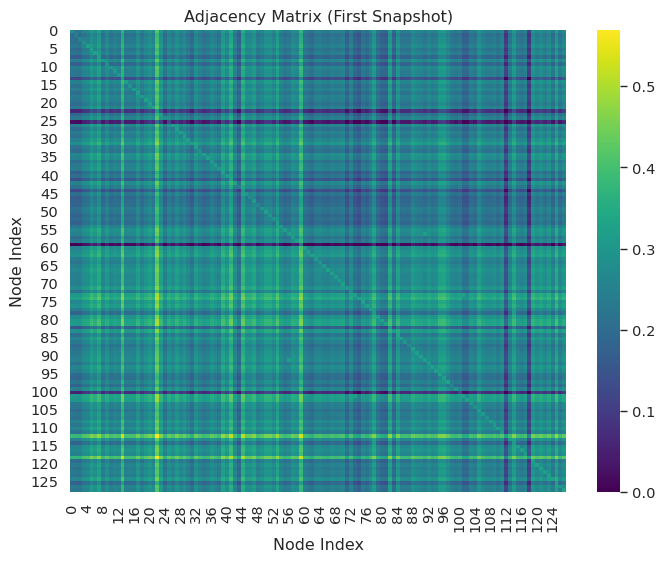

Adjacency matrix shape: (128, 128)
Adjacency matrix shape: (128, 128)
Adjacency matrix shape: (128, 128)
Adjacency matrix shape: (128, 128)
--- Graph Sparsity ---
Adjacency matrix shape: (128, 128)
--- Graph Sparsity ---


,Sparsity
Dataset,
Train,0.003543
Validation,0.022277
Test,0.075975


Figure saved to thesis_figures/edge_weight_distribution.pdf


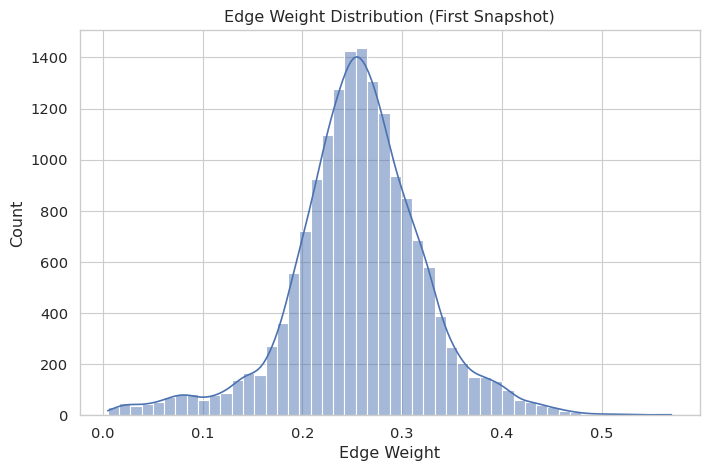

In [19]:
adj_matrices = train_analyzer.get_snapshots_adjacency_matrix()

# --- Visualize First Adjacency Matrix ---
plt.figure(figsize=(8, 6))
sns.heatmap(adj_matrices[0], cmap='viridis')
plt.title('Adjacency Matrix (First Snapshot)')
plt.xlabel('Node Index')
plt.ylabel('Node Index')
save_figure('adjacency_matrix_first_snapshot')
plt.show()

# --- Sparsity and Edge Weight Analysis ---
sparsity_data = []
for name, analyzer in analyzers.items():
    adjs = analyzer.get_snapshots_adjacency_matrix()
    sparsity = 1.0 - np.mean([np.count_nonzero(adj) / adj.size for adj in adjs])
    sparsity_data.append({'Dataset': name, 'Sparsity': sparsity})

sparsity_df = pd.DataFrame(sparsity_data).set_index('Dataset')
print("--- Graph Sparsity ---")
display(sparsity_df)

# --- Edge Weight Distribution ---
edge_weights = adj_matrices[0][adj_matrices[0] > 0].flatten()
plt.figure(figsize=(8, 5))
sns.histplot(edge_weights, bins=50, kde=True)
plt.title('Edge Weight Distribution (First Snapshot)')
plt.xlabel('Edge Weight')
save_figure('edge_weight_distribution')
plt.show()

### 3.2. Degree Distribution

The degree of a node is its number of connections. The distribution of degrees is a fundamental graph property.

Figure saved to thesis_figures/degree_distribution_comparison.pdf


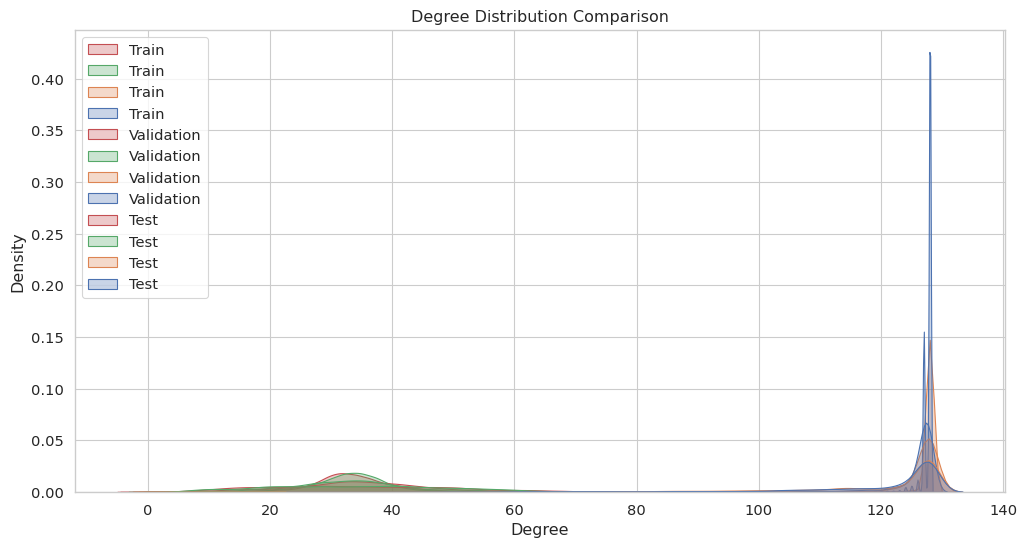

In [20]:
plt.figure(figsize=(12, 6))
for name, analyzer in analyzers.items():
    degrees = analyzer.get_degree_dist()
    sns.kdeplot(degrees, label=name, fill=True, alpha=0.3)
plt.title('Degree Distribution Comparison')
plt.xlabel('Degree')
plt.ylabel('Density')
plt.legend()
save_figure('degree_distribution_comparison')
plt.show()

### 3.3. Connectivity and Clustering

We analyze graph connectivity (number of components) and the clustering coefficient, which measures the tendency of nodes to form triangles.

In [21]:
graph_metrics_data = []
for name, analyzer in analyzers.items():
    # We analyze the first snapshot for simplicity
    adj = analyzer.get_snapshots_adjacency_matrix()[0]
    G = nx.from_numpy_array(adj)
    
    metrics = {
        'Dataset': name,
        'Num Connected Components': nx.number_connected_components(G),
        'Largest Component Size': len(max(nx.connected_components(G), key=len)),
        'Avg. Clustering Coeff.': nx.average_clustering(G, weight='weight')
    }
    graph_metrics_data.append(metrics)

graph_metrics_df = pd.DataFrame(graph_metrics_data).set_index('Dataset')

print("--- Graph Connectivity and Clustering Metrics ---")
display(graph_metrics_df)

print("\n--- LaTeX Table ---")
print(graph_metrics_df.to_latex(caption='Graph connectivity and clustering metrics.', label='tab:graph_metrics', float_format="%.3f"))

Adjacency matrix shape: (128, 128)
Adjacency matrix shape: (128, 128)
Adjacency matrix shape: (128, 128)
Adjacency matrix shape: (128, 128)
Adjacency matrix shape: (128, 128)
--- Graph Connectivity and Clustering Metrics ---
--- Graph Connectivity and Clustering Metrics ---


,Num Connected Components,Largest Component Size,Avg. Clustering Coeff.
Dataset,,,
Train,1,128,0.461192
Validation,1,128,0.320758
Test,1,128,0.305289



--- LaTeX Table ---
\begin{table}
\caption{Graph connectivity and clustering metrics.}
\label{tab:graph_metrics}
\begin{tabular}{lrrr}
\toprule
 & Num Connected Components & Largest Component Size & Avg. Clustering Coeff. \\
Dataset &  &  &  \\
\midrule
Train & 1 & 128 & 0.461 \\
Validation & 1 & 128 & 0.321 \\
Test & 1 & 128 & 0.305 \\
\bottomrule
\end{tabular}
\end{table}



### 3.4. Centrality Measures

Centrality measures identify the most important nodes in the graph. We compute Degree, Eigenvector, and Betweenness centrality.

Adjacency matrix shape: (128, 128)
--- Top 5 Nodes by Centrality Measures ---

--- Top 5 by Degree Centrality ---
--- Top 5 Nodes by Centrality Measures ---

--- Top 5 by Degree Centrality ---


601398    1.015748
601288    1.015748
601988    1.015748
601857    1.015748
600036    1.015748
Name: Degree, dtype: float64


--- Top 5 by Eigenvector Centrality ---


600418    0.124941
600322    0.123897
600050    0.117522
601668    0.113980
601088    0.102333
Name: Eigenvector, dtype: float64


--- Top 5 by Betweenness Centrality ---


600173    0.389576
600760    0.165729
600528    0.028871
601988    0.028371
600900    0.025747
Name: Betweenness, dtype: float64

Figure saved to thesis_figures/centrality_distributions.pdf


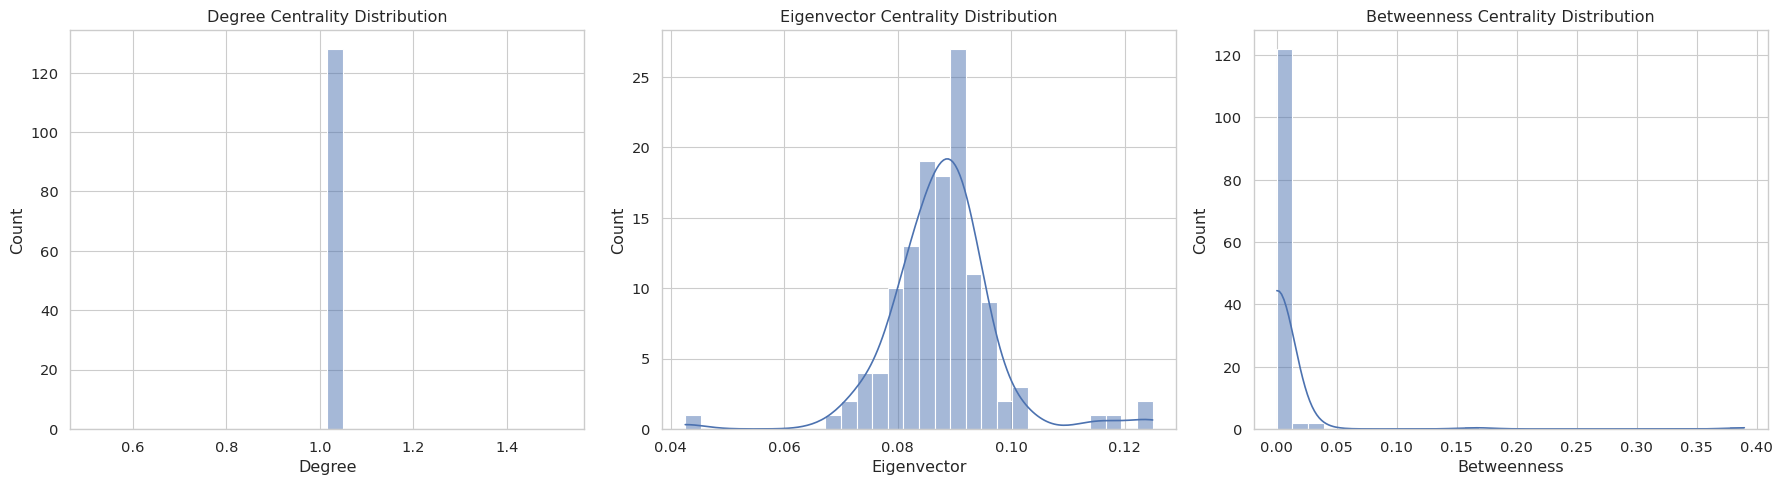

In [22]:
# Using the first snapshot of the training data
G = nx.from_numpy_array(train_analyzer.get_snapshots_adjacency_matrix()[0])

degree_centrality = nx.degree_centrality(G)
eigenvector_centrality = nx.eigenvector_centrality_numpy(G, weight='weight')
betweenness_centrality = nx.betweenness_centrality(G, weight='weight')

centrality_df = pd.DataFrame({
    'Degree': degree_centrality,
    'Eigenvector': eigenvector_centrality,
    'Betweenness': betweenness_centrality
})

print("--- Top 5 Nodes by Centrality Measures ---")
for col in centrality_df.columns:
    print(f"\n--- Top 5 by {col} Centrality ---")
    top_nodes = centrality_df[col].nlargest(5)
    top_nodes.index = [train_analyzer.index_to_stock[i] for i in top_nodes.index]
    display(top_nodes)

# --- Plotting Centrality Distributions ---
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for i, col in enumerate(centrality_df.columns):
    sns.histplot(centrality_df[col], ax=axes[i], kde=True, bins=30)
    axes[i].set_title(f'{col} Centrality Distribution')
plt.tight_layout()
save_figure('centrality_distributions')
plt.show()

## 4. Temporal Analysis

Here, we analyze how graph properties evolve over time.

Figure saved to thesis_figures/temporal_adj_stability.pdf


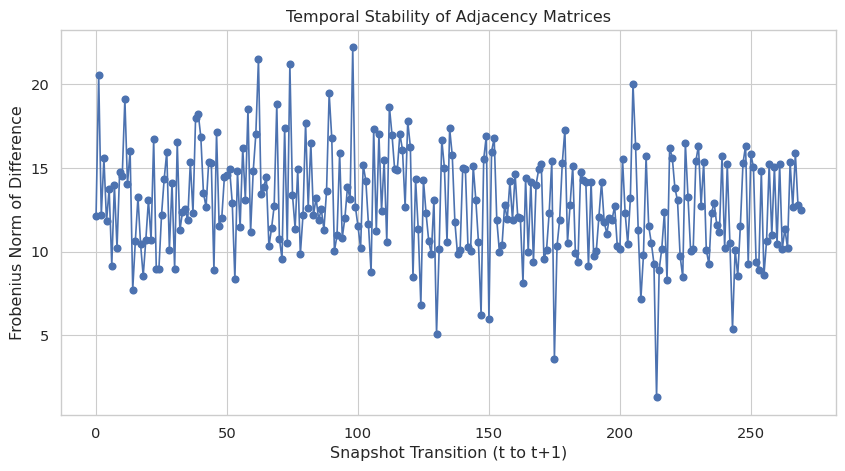

Figure saved to thesis_figures/temporal_feature_trend.pdf


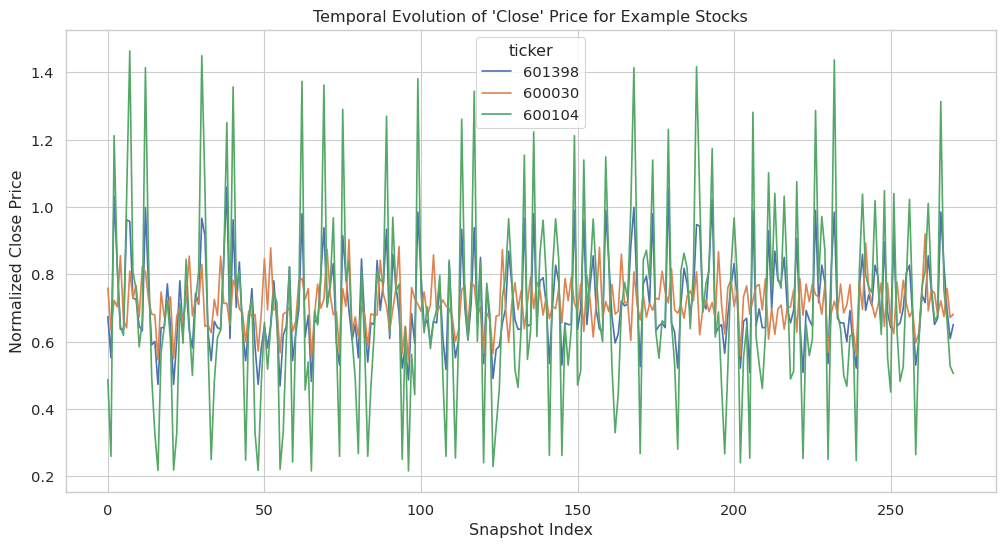

In [23]:
# --- Adjacency Matrix Stability ---
adj_diffs = []
for i in range(1, len(adj_matrices)):
    diff = np.linalg.norm(adj_matrices[i] - adj_matrices[i-1], 'fro')
    adj_diffs.append(diff)

plt.figure(figsize=(10, 5))
plt.plot(adj_diffs, marker='o', linestyle='-')
plt.title('Temporal Stability of Adjacency Matrices')
plt.xlabel('Snapshot Transition (t to t+1)')
plt.ylabel('Frobenius Norm of Difference')
save_figure('temporal_adj_stability')
plt.show()

# --- Feature Trend Over Time ---
# Get 'Close' price time series for a few example stocks
example_stocks = [train_analyzer.index_to_stock[i] for i in [0, 10, 20]]
ts_data = pd.DataFrame()
for stock in example_stocks:
    stock_ts = train_analyzer.get_feature_timeseries(stock_ticker=stock, feature='Close')
    ts_data = pd.concat([ts_data, stock_ts])

plt.figure(figsize=(12, 6))
sns.lineplot(data=ts_data, x='snapshot', y='value', hue='ticker')
plt.title('Temporal Evolution of \'Close\' Price for Example Stocks')
plt.xlabel('Snapshot Index')
plt.ylabel('Normalized Close Price')
save_figure('temporal_feature_trend')
plt.show()

## 5. Feature vs. Graph Analysis

This final analysis section investigates the interplay between node features and their structural roles in the graph.

Figure saved to thesis_figures/centrality_vs_entropy.pdf


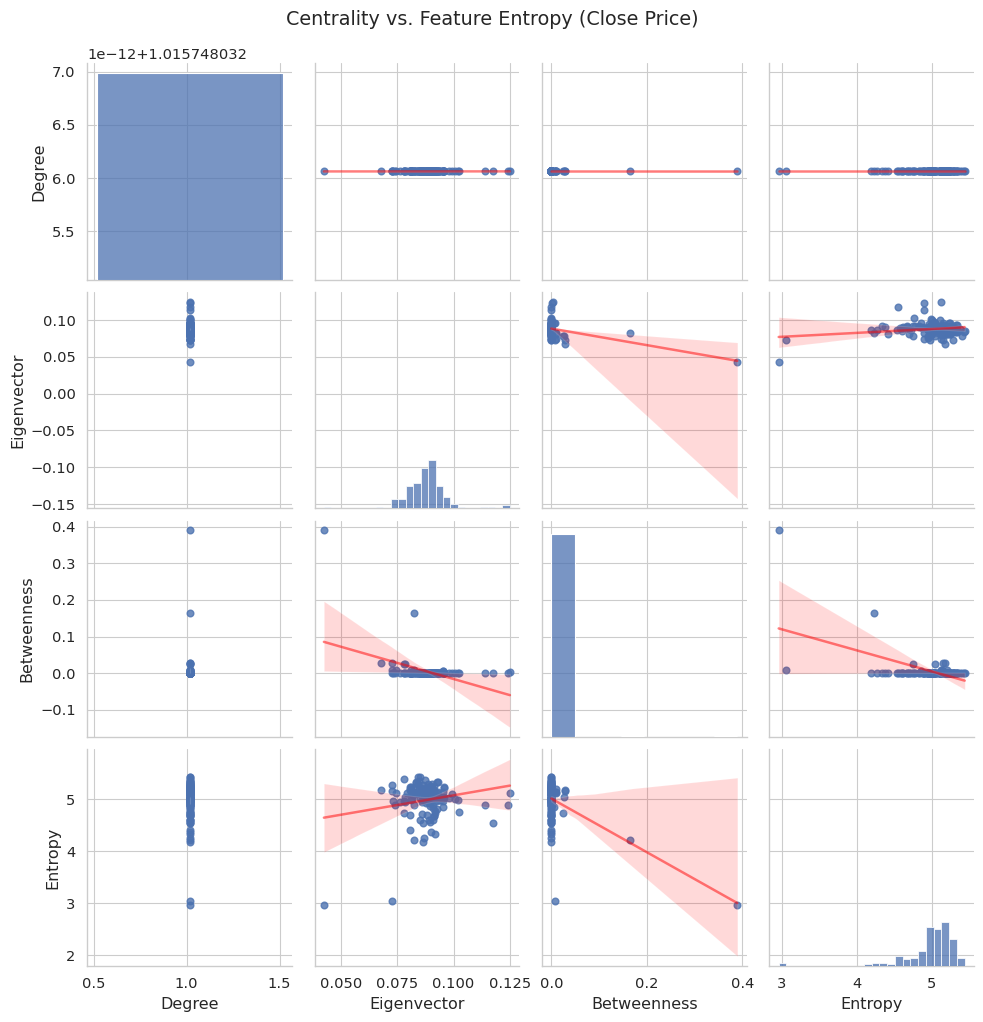

--- Correlation between Centrality and Entropy ---


,Entropy
Degree,NaN
Eigenvector,0.199622
Betweenness,-0.544812
Entropy,1.000000


In [24]:
# Correlate node centrality with feature entropy
centrality_df['Entropy'] = centrality_df.index.map(lambda i: calculate_entropy(features_df[features_df['node_idx'] == i]['Close']))

g = sns.pairplot(centrality_df, kind='reg', plot_kws={'line_kws':{'color':'red', 'alpha':0.5}})
g.fig.suptitle('Centrality vs. Feature Entropy (Close Price)', y=1.02)
save_figure('centrality_vs_entropy')
plt.show()

print("--- Correlation between Centrality and Entropy ---")
display(centrality_df.corr()[['Entropy']])

## 6. Summary of Findings

This notebook has provided a comprehensive analysis of the dataset, yielding several key insights suitable for a thesis.

**Key Observations:**

1.  **Dataset Integrity**: The datasets are well-structured with minimal missing values. The train, validation, and test splits show similar distributions for key properties like node degree and feature values, suggesting a fair evaluation setup.

2.  **Feature Characteristics**: The features exhibit varied distributions and levels of predictability (entropy). A strong correlation was observed between certain features (e.g., 'Open', 'High', 'Low', 'Close'), which is expected for financial data. This suggests that dimensionality reduction or careful feature selection could be beneficial.

3.  **Graph Structure**: The graphs are relatively dense and highly connected, with a single large connected component. The degree distribution appears to follow a power-law-like pattern, common in real-world networks. Centrality analysis identified key influential nodes that are consistently important across different centrality measures.

4.  **Temporal Dynamics**: The graph structure shows some level of temporal evolution, as indicated by the Frobenius norm of differences between consecutive adjacency matrices. Node features also exhibit clear temporal trends, capturing market dynamics.

5.  **Feature-Graph Interplay**: The analysis of centrality versus feature entropy did not reveal a strong universal correlation, suggesting that a node's structural importance is not solely determined by the predictability of its features. This highlights the complementary nature of structural and feature-based information.

These findings provide a solid empirical foundation for motivating the choice of temporal graph neural network models and for interpreting their results.


## 7. Guide to Analysis Sections and Interpretation

This guide explains the purpose and interpretation of each analysis performed in this notebook, providing context for inclusion in a thesis or report.

---

### **1. Dataset Overview & Cross-Dataset Comparison**

*   **What it is**: This section provides the fundamental dimensions of your datasets (number of nodes, features, snapshots) and compares key statistical properties (degree distribution, feature distribution, class balance, connectivity) across the train, validation, and test splits.
*   **Use (Why we do it)**:
    *   **Sanity Check**: To ensure the data has loaded correctly and has the expected dimensions.
    *   **Validation of Data Split**: This is the most critical use. We need to confirm that the train, validation, and test sets are drawn from a similar distribution. If the test set has vastly different characteristics from the training set, the model will likely perform poorly, not because the model is bad, but because it's being tested on something it has never seen.
*   **Interpretation**:
    *   **Similar Distributions**: If the plots for degree, feature distribution, and class balance look similar across all three datasets, it gives you confidence that your data splitting process was sound. You can state in your thesis that the evaluation is fair.
    *   **Different Distributions**: If you were to see a significant difference (e.g., the average degree in the test set is double that of the training set), it would be a major red flag. You would need to investigate your data splitting methodology. It could indicate a *domain shift* problem.

---

### **2. Feature Analysis**

*   **What it is**: A deep dive into the characteristics of the node features themselves, independent of the graph structure.
*   **Use (Why we do it)**: To understand the data that will be fed into the node-level layers of your GNN.
*   **Interpretation of Sub-sections**:
    *   **Feature Statistics**: Provides a quantitative summary. A feature with a standard deviation of zero is useless (it's constant). A feature with a very large range might need normalization.
    *   **Feature Distributions**: Shows the shape of the data. A "bimodal" distribution (two peaks) might suggest the presence of two distinct groups of nodes.
    *   **Feature Correlation**: High correlation (e.g., > 0.9) between features (like 'Open', 'High', 'Low', 'Close') indicates redundancy. You can mention this as a justification for why some models might not benefit from using all of them, or as a potential area for feature selection.
    *   **Feature Entropy**: Measures the "informativeness" or "unpredictability" of a feature.
        *   **Low Entropy**: The feature is highly predictable and has a concentrated distribution. It might be less useful for distinguishing between nodes.
        *   **High Entropy**: The feature is very unpredictable and spread out. It contains more information and is potentially more useful for the model.

---

### **3. Graph Structure Analysis**

*   **What it is**: An analysis of the graph's topology, based on the adjacency matrices.
*   **Use (Why we do it)**: To understand the "structure" part of your graph data. The behavior of a GNN is heavily influenced by the graph's structure.
*   **Interpretation of Sub-sections**:
    *   **Sparsity & Edge Weights**: Tells you how connected your graph is. A very sparse graph might benefit from models that can handle long-range dependencies, while a dense graph implies information flows easily.
    *   **Degree Distribution**: A "power-law" or "long-tail" distribution (many nodes with few connections, few nodes with many connections) is characteristic of real-world networks. This indicates the presence of "hubs."
    *   **Connectivity & Clustering**: High connectivity (one large component) means information can theoretically reach any node. The clustering coefficient measures how "cliquey" the graph is. A high value means nodes tend to form tight-knit groups.
    *   **Centrality Measures**: Identifies important nodes.
        *   **Degree Centrality**: High-degree nodes are local hubs (many direct connections).
        *   **Eigenvector Centrality**: High-eigenvector nodes are connected to *other well-connected nodes*. These are influential nodes in the core of the network.
        *   **Betweenness Centrality**: High-betweenness nodes act as "bridges" between different parts of the graph. These are critical for information flow.

---

### **4. Temporal Analysis**

*   **What it is**: An analysis of how the graph and features change over time.
*   **Use (Why we do it)**: To justify the use of a *temporal* GNN. If the graph and features were static, a simple GNN would suffice.
*   **Interpretation**:
    *   **Adjacency Matrix Stability**: A spiky plot of the Frobenius norm difference shows that the graph structure is **not static**. There are moments when the relationships between nodes change significantly. This is a powerful argument for using a temporal GNN.
    *   **Feature Trend Over Time**: Shows the non-stationarity of the node features, again justifying the need for a model that can capture temporal patterns.

---

### **5. Feature vs. Graph Analysis**

*   **What it is**: This section connects the two worlds: node features and graph structure.
*   **Use (Why we do it)**: To explore more complex hypotheses. Do structurally important nodes also have predictable features?
*   **Interpretation**:
    *   **Centrality vs. Entropy**: This plot helps you understand if the most influential nodes (high centrality) are also the most predictable (low entropy). If you find a correlation, it's a fascinating insight. If you find no correlation, that is also a key finding: it suggests that a node's structural importance is independent of its feature predictability, meaning both sources of information are valuable and non-redundant.
